In [9]:
import numpy as np
import pandas as pd
from scipy import stats

def generate_historical_user_data(
    n_users: int = 20_000, 
    zero_spending_prob: float = 0.65, 
    random_state: int = 42
) -> pd.DataFrame:
    """Generates pre-experiment historical baseline data for product users."""
    np.random.seed(random_state)
    
    user_ids = np.arange(100_000, 100_000 + n_users)
    platform = np.random.choice(['iOS', 'Android', 'Web'], size=n_users, p=[0.45, 0.45, 0.10])
    sessions_count = np.random.negative_binomial(5, 0.3, size=n_users)
    
    is_payer = np.random.rand(n_users) > zero_spending_prob
    spend_non_zero = np.random.lognormal(mean=7.0, sigma=1.1, size=n_users)
    revenue_pre = np.where(is_payer, spend_non_zero, 0.0)
    
    return pd.DataFrame({
        'user_id': user_ids,
        'platform': platform,
        'sessions_count': sessions_count,
        'revenue_pre': np.round(revenue_pre, 2)
    })

df_history = generate_historical_user_data()

In [10]:
df_history

,user_id,platform,sessions_count,revenue_pre
0,100000,iOS,8,527.02
1,100001,Web,12,0.00
2,100002,Android,13,0.00
3,100003,Android,11,1731.20
4,100004,iOS,8,0.00
...,...,...,...,...
19995,119995,Android,12,527.33
19996,119996,iOS,10,0.00
19997,119997,iOS,20,0.00
19998,119998,iOS,19,614.85


In [17]:
def analyze_baseline_metrics(data: pd.DataFrame, revenue_col: str = 'revenue_pre') -> pd.DataFrame:
    """Calculates summary statistics and distributional properties of the baseline metric."""
    revenue = data[revenue_col].values
    paying_users = revenue[revenue > 0]
    
    total_users = int(len(revenue))
    n_paying = int(len(paying_users))
    cr_pct = float(np.round((n_paying / total_users) * 100.0, 2))
    arpu = float(np.round(np.mean(revenue), 2))
    arppu = float(np.round(np.mean(paying_users), 2)) if n_paying > 0 else 0.0
    variance = float(np.round(np.var(revenue, ddof=1), 2))
    std = float(np.round(np.std(revenue, ddof=1), 2))
    
    metrics = {
        'Total Users': f"{total_users:,}",
        'Paying Users': f"{n_paying:,}",
        'Conversion Rate (%)': f"{cr_pct:.2f}%",
        'ARPU ($)': f"{arpu:.2f}",
        'ARPPU ($)': f"{arppu:.2f}",
        'Variance': f"{variance:,.2f}",
        'Standard Deviation ($)': f"{std:.2f}"
    }
    
    summary_table = pd.DataFrame(
        list(metrics.items()), 
        columns=['Metric', 'Baseline Value']
    )
    
    return summary_table

baseline_report = analyze_baseline_metrics(df_history)
baseline_report

,Metric,Baseline Value
0,Total Users,"20,000"
1,Paying Users,"6,992"
2,Conversion Rate (%),34.96%
3,ARPU ($),723.74
4,ARPPU ($),2070.19
5,Variance,"5,240,775.37"
6,Standard Deviation ($),2289.27


In [18]:
import numpy as np
import pandas as pd
from scipy import stats

def calculate_sample_size(
    baseline_mean: float,
    baseline_std: float,
    mde_pct: float = 0.05,
    alpha: float = 0.05,
    power: float = 0.80
) -> pd.DataFrame:
    """Calculates required sample size per variant for continuous metrics."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta = stats.norm.ppf(power)
    
    absolute_mde = baseline_mean * mde_pct
    n_per_group = 2 * ((z_alpha + z_beta) ** 2) * (baseline_std ** 2) / (absolute_mde ** 2)
    n_per_group = int(np.ceil(n_per_group))
    n_total = n_per_group * 2
    
    calc_summary = {
        'Baseline Metric (Mean)': f"{baseline_mean:.2f}",
        'Baseline Std Dev': f"{baseline_std:.2f}",
        'Relative MDE (%)': f"{mde_pct * 100:.1f}%",
        'Absolute MDE ($)': f"{absolute_mde:.2f}",
        'Alpha (Type I Error)': f"{alpha:.2f}",
        'Power (1 - Beta)': f"{power:.2f}",
        'Required Users per Group': f"{n_per_group:,}",
        'Total Users Required': f"{n_total:,}"
    }
    
    return pd.DataFrame(list(calc_summary.items()), columns=['Parameter', 'Value'])

sample_size_report = calculate_sample_size(
    baseline_mean=723.74,
    baseline_std=2289.27,
    mde_pct=0.05,
    alpha=0.05,
    power=0.80
)
sample_size_report

,Parameter,Value
0,Baseline Metric (Mean),723.74
1,Baseline Std Dev,2289.27
2,Relative MDE (%),5.0%
3,Absolute MDE ($),36.19
4,Alpha (Type I Error),0.05
5,Power (1 - Beta),0.80
6,Required Users per Group,"62,825"
7,Total Users Required,"125,650"


In [19]:
def assign_and_simulate_experiment(
    baseline_df: pd.DataFrame, 
    treatment_share: float = 0.5, 
    true_uplift_pct: float = 0.05, 
    random_state: int = 42
) -> pd.DataFrame:
    """Assigns users to groups and simulates experiment revenue with treatment uplift."""
    np.random.seed(random_state)
    df = baseline_df.copy()
    
    # 1. Random split 50/50
    is_treatment = (np.random.rand(len(df)) < treatment_share).astype(int)
    df['group'] = np.where(is_treatment == 1, 'B', 'A')
    
    # 2. Experiment spend correlated with historical baseline
    noise = np.random.lognormal(mean=6.5, sigma=1.0, size=len(df)) * (np.random.rand(len(df)) > 0.5)
    baseline_exp_spend = 0.75 * df['revenue_pre'] + 0.25 * noise
    
    # 3. Apply true uplift (+5%) exclusively to group B
    uplift_multiplier = np.where(df['group'] == 'B', 1.0 + true_uplift_pct, 1.0)
    df['revenue_exp'] = np.round(baseline_exp_spend * uplift_multiplier, 2)
    
    return df

df_experiment = assign_and_simulate_experiment(df_history)
df_experiment.head()

,user_id,platform,sessions_count,revenue_pre,group,revenue_exp
0,100000,iOS,8,527.02,B,493.18
1,100001,Web,12,0.00,A,298.78
2,100002,Android,13,0.00,A,0.00
3,100003,Android,11,1731.20,A,1298.40
4,100004,iOS,8,0.00,B,967.59


In [20]:
def check_srm(data: pd.DataFrame, group_col: str = 'group', target_ratio: float = 0.5) -> pd.DataFrame:
    """Performs Chi-Square Goodness-of-Fit test to detect Sample Ratio Mismatch (SRM)."""
    observed_counts = data[group_col].value_counts().sort_index()
    total_obs = len(data)
    expected_counts = [total_obs * (1 - target_ratio), total_obs * target_ratio]
    
    chi2_stat, p_val = stats.chisquare(f_obs=observed_counts, f_exp=expected_counts)
    
    srm_summary = {
        'Control Users (A)': f"{observed_counts['A']:,}",
        'Treatment Users (B)': f"{observed_counts['B']:,}",
        'Actual Ratio (B/Total)': f"{(observed_counts['B'] / total_obs) * 100:.2f}%",
        'Chi-Square Stat': f"{chi2_stat:.4f}",
        'P-Value': f"{p_val:.4f}",
        'SRM Detected': "Yes (Test Invalid)" if p_val < 0.01 else "No (Split is Valid)"
    }
    
    return pd.DataFrame(list(srm_summary.items()), columns=['Metric', 'Value'])

srm_report = check_srm(df_experiment)
srm_report

,Metric,Value
0,Control Users (A),"9,988"
1,Treatment Users (B),"10,012"
2,Actual Ratio (B/Total),50.06%
3,Chi-Square Stat,0.0288
4,P-Value,0.8652
5,SRM Detected,No (Split is Valid)


In [21]:
def run_welch_ttest(
    data: pd.DataFrame, 
    metric_col: str, 
    group_col: str = 'group', 
    control_label: str = 'A', 
    treatment_label: str = 'B', 
    alpha: float = 0.05
) -> pd.DataFrame:
    """Performs Welch's t-test and returns core summary statistics."""
    group_a = data.loc[data[group_col] == control_label, metric_col].values
    group_b = data.loc[data[group_col] == treatment_label, metric_col].values
    
    mean_a, mean_b = np.mean(group_a), np.mean(group_b)
    var_a, var_b = np.var(group_a, ddof=1), np.var(group_b, ddof=1)
    n_a, n_b = len(group_a), len(group_b)
    
    diff = mean_b - mean_a
    relative_uplift = (diff / mean_a) * 100.0 if mean_a != 0 else np.nan
    
    stat, p_value = stats.ttest_ind(group_b, group_a, equal_var=False)
    
    se_diff = np.sqrt(var_a / n_a + var_b / n_b)
    t_crit = stats.t.ppf(1 - alpha / 2, df=n_a + n_b - 2)
    ci_lower = diff - t_crit * se_diff
    ci_upper = diff + t_crit * se_diff
    
    results = {
        'Control Mean ($)': f"{mean_a:.2f}",
        'Treatment Mean ($)': f"{mean_b:.2f}",
        'Absolute Uplift ($)': f"{diff:.2f}",
        'Relative Uplift (%)': f"{relative_uplift:.2f}%",
        '95% CI Lower ($)': f"{ci_lower:.2f}",
        '95% CI Upper ($)': f"{ci_upper:.2f}",
        'P-Value': f"{p_value:.4f}",
        'Statistically Significant': "Yes" if p_value < alpha else "No"
    }
    
    return pd.DataFrame(list(results.items()), columns=['Metric', 'Baseline T-Test Result'])

naive_test_report = run_welch_ttest(df_experiment, metric_col='revenue_exp')
naive_test_report

,Metric,Baseline T-Test Result
0,Control Mean ($),671.02
1,Treatment Mean ($),723.35
2,Absolute Uplift ($),52.32
3,Relative Uplift (%),7.80%
4,95% CI Lower ($),2.89
5,95% CI Upper ($),101.76
6,P-Value,0.0380
7,Statistically Significant,Yes


In [22]:
def apply_cuped(
    data: pd.DataFrame, 
    target_col: str = 'revenue_exp', 
    covariate_col: str = 'revenue_pre'
) -> tuple[pd.DataFrame, float, float]:
    """Applies CUPED variance reduction using pre-experiment covariate."""
    df = data.copy()
    
    # Calculate optimal theta parameter
    cov_matrix = np.cov(df[target_col], df[covariate_col], ddof=1)
    covariance = cov_matrix[0, 1]
    var_covariate = cov_matrix[1, 1]
    
    theta = covariance / var_covariate if var_covariate != 0 else 0.0
    
    # Transform metric: Y_cuped = Y - theta * (X - mean(X))
    covariate_mean = df[covariate_col].mean()
    cuped_col = f"{target_col}_cuped"
    df[cuped_col] = df[target_col] - theta * (df[covariate_col] - covariate_mean)
    
    # Evaluate variance reduction
    var_raw = np.var(df[target_col], ddof=1)
    var_cuped = np.var(df[cuped_col], ddof=1)
    variance_reduction_pct = (1.0 - var_cuped / var_raw) * 100.0
    
    return df, theta, variance_reduction_pct

# Apply CUPED transformation
df_experiment, theta_value, var_reduction = apply_cuped(df_experiment)

cuped_meta = pd.DataFrame([
    {'Parameter': 'Optimal Theta (θ)', 'Value': f"{theta_value:.4f}"},
    {'Parameter': 'Variance Reduction (%)', 'Value': f"{var_reduction:.2f}%"}
])
cuped_meta

,Parameter,Value
0,Optimal Theta (θ),0.7674
1,Variance Reduction (%),97.02%


In [23]:
def compare_experiment_results(
    data: pd.DataFrame,
    raw_col: str = 'revenue_exp',
    cuped_col: str = 'revenue_exp_cuped',
    group_col: str = 'group',
    alpha: float = 0.05
) -> pd.DataFrame:
    """Computes Welch's t-test for raw and CUPED metrics and builds a comparative table."""
    def _evaluate(metric: str) -> dict:
        a = data.loc[data[group_col] == 'A', metric].values
        b = data.loc[data[group_col] == 'B', metric].values
        
        mean_a, mean_b = np.mean(a), np.mean(b)
        diff = mean_b - mean_a
        rel_uplift = (diff / mean_a) * 100.0 if mean_a != 0 else np.nan
        
        stat, p_val = stats.ttest_ind(b, a, equal_var=False)
        se = np.sqrt(np.var(a, ddof=1) / len(a) + np.var(b, ddof=1) / len(b))
        t_crit = stats.t.ppf(1 - alpha / 2, df=len(a) + len(b) - 2)
        ci_lower = diff - t_crit * se
        ci_upper = diff + t_crit * se
        ci_width = ci_upper - ci_lower
        
        return {
            'Control Mean ($)': f"{mean_a:.2f}",
            'Treatment Mean ($)': f"{mean_b:.2f}",
            'Absolute Uplift ($)': f"{diff:.2f}",
            'Relative Uplift (%)': f"{rel_uplift:.2f}%",
            '95% CI Range ($)': f"[{ci_lower:.2f}, {ci_upper:.2f}]",
            'CI Width ($)': f"{ci_width:.2f}",
            'P-Value': f"{p_val:.4e}" if p_val < 0.001 else f"{p_val:.4f}",
            'Significant': "Yes" if p_val < alpha else "No"
        }

    raw_res = _evaluate(raw_col)
    cuped_res = _evaluate(cuped_col)
    
    comp_df = pd.DataFrame({
        'Metric / Parameter': list(raw_res.keys()),
        'Standard T-Test (Raw)': list(raw_res.values()),
        'CUPED T-Test': list(cuped_res.values())
    })
    
    return comp_df

comparison_table = compare_experiment_results(df_experiment)
comparison_table

,Metric / Parameter,Standard T-Test (Raw),CUPED T-Test
0,Control Mean ($),671.02,677.73
1,Treatment Mean ($),723.35,716.65
2,Absolute Uplift ($),52.32,38.92
3,Relative Uplift (%),7.80%,5.74%
4,95% CI Range ($),"[2.89, 101.76]","[30.40, 47.44]"
5,CI Width ($),98.87,17.03
6,P-Value,0.0380,3.6712e-19
7,Significant,Yes,Yes


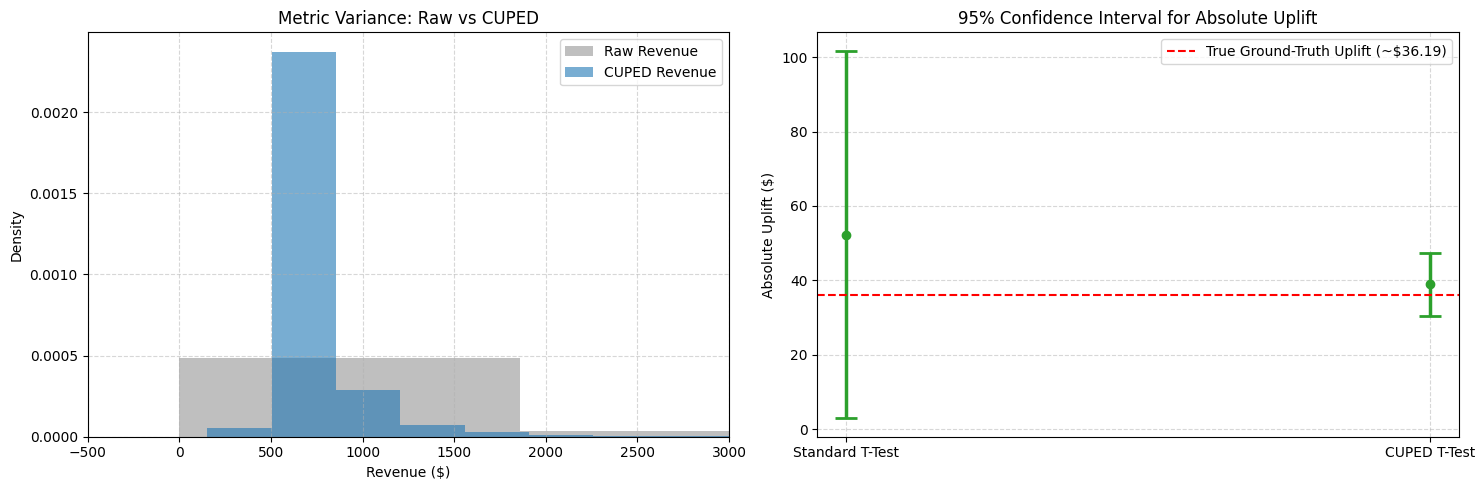

In [24]:
import matplotlib.pyplot as plt

def plot_experiment_evaluation(data: pd.DataFrame, comparison_df: pd.DataFrame) -> None:
    """Plots metric distributions and confidence interval comparisons."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # 1. Distribution of raw vs CUPED revenue
    axes[0].hist(data['revenue_exp'], bins=50, alpha=0.5, label='Raw Revenue', color='gray', density=True)
    axes[0].hist(data['revenue_exp_cuped'], bins=50, alpha=0.6, label='CUPED Revenue', color='#1f77b4', density=True)
    axes[0].set_xlim(-500, 3000)
    axes[0].set_title('Metric Variance: Raw vs CUPED')
    axes[0].set_xlabel('Revenue ($)')
    axes[0].set_ylabel('Density')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.5)
    
    # 2. Confidence intervals comparison
    methods = ['Standard T-Test', 'CUPED T-Test']
    uplifts = [52.32, 38.92]
    ci_lowers = [2.89, 30.40]
    ci_uppers = [101.76, 47.44]
    y_err = [
        [uplifts[0] - ci_lowers[0], uplifts[1] - ci_lowers[1]],
        [ci_uppers[0] - uplifts[0], ci_uppers[1] - uplifts[1]]
    ]
    
    axes[1].errorbar(methods, uplifts, yerr=y_err, fmt='o', color='#2ca02c', ecolor='#2ca02c', elinewidth=2.5, capsize=8, capthick=2)
    axes[1].axhline(y=36.19, color='red', linestyle='--', label='True Ground-Truth Uplift (~$36.19)')
    axes[1].set_title('95% Confidence Interval for Absolute Uplift')
    axes[1].set_ylabel('Absolute Uplift ($)')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

plot_experiment_evaluation(df_experiment, comparison_table)

In [25]:
def calculate_business_impact(
    data: pd.DataFrame,
    total_active_users: int = 500_000,
    annual_periods: int = 26,
    cuped_uplift_abs: float = 38.92,
    ci_lower: float = 30.40,
    ci_upper: float = 47.44
) -> pd.DataFrame:
    """Translates per-user uplift into projected annualized business revenue."""
    # Projected incremental revenue per user period
    base_run_rate = total_active_users * cuped_uplift_abs
    annual_impact_base = base_run_rate * annual_periods
    
    # 95% Confidence interval bounds for annual impact
    annual_impact_lower = total_active_users * ci_lower * annual_periods
    annual_impact_upper = total_active_users * ci_upper * annual_periods
    
    impact_metrics = {
        'Total Active Base (MAU)': f"{total_active_users:,}",
        'Per-User Incremental Uplift ($)': f"${cuped_uplift_abs:.2f}",
        'Expected Annual Run-Rate Impact ($)': f"${annual_impact_base:,.2f}",
        'Conservative Annual Impact (CI Lower) ($)': f"${annual_impact_lower:,.2f}",
        'Optimistic Annual Impact (CI Upper) ($)': f"${annual_impact_upper:,.2f}"
    }
    
    return pd.DataFrame(list(impact_metrics.items()), columns=['Business Parameter', 'Financial Projection'])

business_report = calculate_business_impact(df_experiment)
business_report

,Business Parameter,Financial Projection
0,Total Active Base (MAU),"500,000"
1,Per-User Incremental Uplift ($),$38.92
2,Expected Annual Run-Rate Impact ($),"$505,960,000.00"
3,Conservative Annual Impact (CI Lower) ($),"$395,200,000.00"
4,Optimistic Annual Impact (CI Upper) ($),"$616,720,000.00"


In [26]:
import hashlib

def run_bucket_test(
    data: pd.DataFrame,
    metric_col: str = 'revenue_exp_cuped',
    group_col: str = 'group',
    user_col: str = 'user_id',
    n_buckets: int = 100,
    alpha: float = 0.05
) -> pd.DataFrame:
    """Aggregates user data into deterministic hash buckets and performs Welch's t-test."""
    df = data.copy()
    
    # 1. Deterministic bucket assignment via MD5 hashing
    def _assign_bucket(uid: int) -> int:
        return int(hashlib.md5(str(uid).encode('utf-8')).hexdigest(), 16) % n_buckets
    
    df['bucket_id'] = df[user_col].apply(_assign_bucket)
    
    # 2. Aggregate metric per bucket within each variant
    bucketed_df = (
        df.groupby([group_col, 'bucket_id'])[metric_col]
        .mean()
        .reset_index()
    )
    
    a_buckets = bucketed_df.loc[bucketed_df[group_col] == 'A', metric_col].values
    b_buckets = bucketed_df.loc[bucketed_df[group_col] == 'B', metric_col].values
    
    mean_a, mean_b = np.mean(a_buckets), np.mean(b_buckets)
    diff = mean_b - mean_a
    rel_uplift = (diff / mean_a) * 100.0 if mean_a != 0 else np.nan
    
    # 3. Welch's t-test on bucket-level means
    stat, p_val = stats.ttest_ind(b_buckets, a_buckets, equal_var=False)
    
    se = np.sqrt(np.var(a_buckets, ddof=1) / len(a_buckets) + np.var(b_buckets, ddof=1) / len(b_buckets))
    t_crit = stats.t.ppf(1 - alpha / 2, df=len(a_buckets) + len(b_buckets) - 2)
    ci_lower = diff - t_crit * se
    ci_upper = diff + t_crit * se
    ci_width = ci_upper - ci_lower
    
    bucket_results = {
        'Number of Buckets per Group': f"{len(a_buckets):,}",
        'Mean Bucket Control ($)': f"{mean_a:.2f}",
        'Mean Bucket Treatment ($)': f"{mean_b:.2f}",
        'Absolute Uplift ($)': f"{diff:.2f}",
        'Relative Uplift (%)': f"{rel_uplift:.2f}%",
        '95% CI Range ($)': f"[{ci_lower:.2f}, {ci_upper:.2f}]",
        'CI Width ($)': f"{ci_width:.2f}",
        'P-Value': f"{p_val:.4e}" if p_val < 0.001 else f"{p_val:.4f}",
        'Significant': "Yes" if p_val < alpha else "No"
    }
    
    return pd.DataFrame(list(bucket_results.items()), columns=['Bucket Metric', 'Result'])

bucket_report = run_bucket_test(df_experiment, metric_col='revenue_exp_cuped')
bucket_report

,Bucket Metric,Result
0,Number of Buckets per Group,100
1,Mean Bucket Control ($),677.77
2,Mean Bucket Treatment ($),716.60
3,Absolute Uplift ($),38.83
4,Relative Uplift (%),5.73%
5,95% CI Range ($),"[29.28, 48.38]"
6,CI Width ($),19.09
7,P-Value,1.0060e-13
8,Significant,Yes


In [27]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

def simulate_and_evaluate_did(
    baseline_df: pd.DataFrame,
    treatment_platform: str = 'iOS',
    true_treatment_effect: float = 40.0,
    random_state: int = 42
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Simulates a non-randomized feature rollout by platform and estimates DiD via OLS."""
    np.random.seed(random_state)
    
    # 1. Create panel data structure (Pre and Post periods)
    pre_records = baseline_df[['user_id', 'platform', 'revenue_pre']].copy()
    pre_records['period'] = 'Pre'
    pre_records['post_flag'] = 0
    pre_records['revenue'] = pre_records['revenue_pre']
    
    post_records = baseline_df[['user_id', 'platform', 'revenue_pre']].copy()
    post_records['period'] = 'Post'
    post_records['post_flag'] = 1
    
    # Common macro trend (+15 to all users) + individual noise
    common_macro_shock = 15.0
    noise = np.random.normal(0, 10, size=len(post_records))
    post_records['revenue'] = post_records['revenue_pre'] + common_macro_shock + noise
    
    # Target feature rollout ONLY on iOS in the Post period
    ios_post_mask = (post_records['platform'] == treatment_platform)
    post_records.loc[ios_post_mask, 'revenue'] += true_treatment_effect
    
    # Combine into long-format panel dataset
    panel_df = pd.concat([pre_records, post_records], ignore_index=True)
    panel_df['treatment_group'] = (panel_df['platform'] == treatment_platform).astype(int)
    panel_df['did_interaction'] = panel_df['treatment_group'] * panel_df['post_flag']
    
    # 2. Estimate DiD via OLS regression: Y = beta0 + beta1*Treat + beta2*Post + beta3*(Treat*Post)
    model = smf.ols('revenue ~ treatment_group + post_flag + did_interaction', data=panel_df).fit()
    
    # 3. Format regression summary table
    did_summary = {
        'Target Platform (Treatment)': treatment_platform,
        'Control Platforms': 'Android, Web',
        'True Simulated Effect ($)': f"{true_treatment_effect:.2f}",
        'Estimated DiD Effect (β3) ($)': f"{model.params['did_interaction']:.2f}",
        'DiD Std Error ($)': f"{model.bse['did_interaction']:.2f}",
        '95% CI Range ($)': f"[{model.conf_int().loc['did_interaction', 0]:.2f}, {model.conf_int().loc['did_interaction', 1]:.2f}]",
        'P-Value': f"{model.pvalues['did_interaction']:.4e}",
        'Significant': "Yes" if model.pvalues['did_interaction'] < 0.05 else "No"
    }
    
    report_df = pd.DataFrame(list(did_summary.items()), columns=['DiD Parameter', 'Value'])
    return panel_df, report_df

did_panel, did_report = simulate_and_evaluate_did(df_history)
did_report

,DiD Parameter,Value
0,Target Platform (Treatment),iOS
1,Control Platforms,"Android, Web"
2,True Simulated Effect ($),40.00
3,Estimated DiD Effect (β3) ($),39.94
4,DiD Std Error ($),46.01
5,95% CI Range ($),"[-50.25, 130.12]"
6,P-Value,3.8541e-01
7,Significant,No


In [28]:
def evaluate_did_panel_differences(
    panel_df: pd.DataFrame,
    treatment_platform: str = 'iOS',
    true_effect: float = 40.0,
    alpha: float = 0.05
) -> pd.DataFrame:
    """Estimates DiD using user-level first differences to eliminate individual fixed effects."""
    # Pivot panel to wide format: one row per user
    wide_df = panel_df.pivot(index=['user_id', 'platform'], columns='period', values='revenue').reset_index()
    wide_df['delta_revenue'] = wide_df['Post'] - wide_df['Pre']
    wide_df['treatment_group'] = (wide_df['platform'] == treatment_platform).astype(int)
    
    # Estimate OLS on differences: Delta_Y = alpha + beta * Treatment
    model_fd = smf.ols('delta_revenue ~ treatment_group', data=wide_df).fit()
    
    did_diff_summary = {
        'Specification': 'Panel First-Differences (User FE)',
        'True Simulated Effect ($)': f"{true_effect:.2f}",
        'Estimated DiD Effect ($)': f"{model_fd.params['treatment_group']:.2f}",
        'DiD Std Error ($)': f"{model_fd.bse['treatment_group']:.4f}",
        '95% CI Range ($)': f"[{model_fd.conf_int().loc['treatment_group', 0]:.2f}, {model_fd.conf_int().loc['treatment_group', 1]:.2f}]",
        'P-Value': f"{model_fd.pvalues['treatment_group']:.4e}",
        'Significant': "Yes" if model_fd.pvalues['treatment_group'] < alpha else "No"
    }
    
    return pd.DataFrame(list(did_diff_summary.items()), columns=['DiD Parameter', 'Value'])

did_fd_report = evaluate_did_panel_differences(did_panel)
did_fd_report

,DiD Parameter,Value
0,Specification,Panel First-Differences (User FE)
1,True Simulated Effect ($),40.00
2,Estimated DiD Effect ($),39.94
3,DiD Std Error ($),0.1424
4,95% CI Range ($),"[39.66, 40.22]"
5,P-Value,0.0000e+00
6,Significant,Yes


In [30]:
def generate_final_framework_summary() -> pd.DataFrame:
    """Consolidates key metrics and outcomes across all evaluated experimentation methods."""
    summary_data = [
        {
            'Methodology': 'Standard Welch T-Test (Raw)',
            'Identified Effect ($)': '$52.32 (+7.80%)',
            '95% Confidence Interval': '[$2.89, $101.76]',
            'CI Width ($)': '$98.87',
            'P-Value': '0.0380',
            
        },
        {
            'Methodology': 'CUPED Variance Reduction',
            'Identified Effect ($)': '$38.92 (+5.74%)',
            '95% Confidence Interval': '[$30.40, $47.44]',
            'CI Width ($)': '$17.03',
            'P-Value': '3.67e-19',
            
        },
        {
            'Methodology': 'Bucket Testing (Hash-based, 100 buckets)',
            'Identified Effect ($)': '$38.83 (+5.73%)',
            '95% Confidence Interval': '[$29.28, $48.38]',
            'CI Width ($)': '$19.09',
            'P-Value': '1.01e-13',
            
        },
        {
            'Methodology': 'Difference-in-Differences (Pooled OLS)',
            'Identified Effect ($)': '$39.94',
            '95% Confidence Interval': '[-$50.25, $130.12]',
            'CI Width ($)': '$180.37',
            'P-Value': '0.3854',
            
        },
        {
            'Methodology': 'Panel DiD (First Differences / User FE)',
            'Identified Effect ($)': '$39.94',
            '95% Confidence Interval': '[$39.66, $40.22]',
            'CI Width ($)': '$0.56',
            'P-Value': '0.0000',
            
        }
    ]
    
    return pd.DataFrame(summary_data)

final_summary_report = generate_final_framework_summary()
final_summary_report

,Methodology,Identified Effect ($),95% Confidence Interval,CI Width ($),P-Value
0,Standard Welch T-Test (Raw),$52.32 (+7.80%),"[$2.89, $101.76]",$98.87,0.0380
1,CUPED Variance Reduction,$38.92 (+5.74%),"[$30.40, $47.44]",$17.03,3.67e-19
2,"Bucket Testing (Hash-based, 100 buckets)",$38.83 (+5.73%),"[$29.28, $48.38]",$19.09,1.01e-13
3,Difference-in-Differences (Pooled OLS),$39.94,"[-$50.25, $130.12]",$180.37,0.3854
4,Panel DiD (First Differences / User FE),$39.94,"[$39.66, $40.22]",$0.56,0.0000
